# 03 · OE4 — Conglomerados (análisis de conglomerados)
**Iván Ramiro Pinzón Pinto** — Ciencia de Datos, Universidad Externado de Colombia · Tutora: Yessica Velásquez

*Implementa §3.7 (análisis de conglomerados, validación de la partición y pruebas estadísticas).* **Requiere `02_OE2-OE3_ICP_IPD`.**

In [1]:
# Bloque de librerías común a los cuadernos 00-04 (algunos módulos se usan solo en 02-04)
import pandas as pd
import numpy as np
import json
import re
import os
import warnings
from glob import glob
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, silhouette_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from itertools import combinations
from matplotlib.patches import Patch
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.inspection import permutation_importance
from sklearn.metrics import adjusted_rand_score, silhouette_samples
import lightgbm as lgb
import shap

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("Librerías cargadas correctamente.")

c:\Users\ivanr\.conda\envs\pyfhel\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías cargadas correctamente.


In [2]:
from matplotlib.ticker import FuncFormatter

def num_co(x, dec=None):
    """Número con coma decimal y punto de miles. dec=None: decimales necesarios."""
    if dec is None:
        s = f'{x:,.6f}'.rstrip('0').rstrip('.')
        if s in ('', '-', '-0'):
            s = '0'
    else:
        s = f'{x:,.{dec}f}'
    return s.replace(',', '§').replace('.', ',').replace('§', '.')

def eje_co(dec=None):
    """FuncFormatter de ejes numéricos en convención colombiana."""
    return FuncFormatter(lambda v, _: num_co(v, dec))

_SUP = str.maketrans('-0123456789', '⁻⁰¹²³⁴⁵⁶⁷⁸⁹')

def p_apa(p):
    """Valor p en estilo APA 7: 'p = 0,032' o 'p = 5,4 × 10⁻⁹'."""
    if p >= 0.001:
        return f'p = {num_co(p, 3)}'
    e = int(np.floor(np.log10(p)))
    m = p / 10 ** e
    if round(m, 1) >= 10:   # 9,96 redondearía a 10,0 -> pasa a 1,0 × 10^(e+1)
        m, e = m / 10, e + 1
    return f'p = {num_co(m, 1)} × 10{str(e).translate(_SUP)}'

print('Formato de figuras cargado (num_co, eje_co, p_apa).')

Formato de figuras cargado (num_co, eje_co, p_apa).


## Carga de insumos

Se carga el panel con ICP/IPD del cuaderno 02 y se recompone `habiles` (días hábiles no festivos, **todos los meses**): es la misma ventana de análisis del IPD (§3.5–3.6) y la que define los perfiles que se agrupan.

In [3]:
import os
import pandas as pd

RAIZ = os.getcwd()
if os.path.basename(RAIZ) == 'notebooks':
    RAIZ = os.path.dirname(RAIZ)
DATA_INT = os.path.join(RAIZ, 'data', 'intermedia')
OUT_FIG  = os.path.join(RAIZ, 'outputs', 'figuras')
OUT_TAB  = os.path.join(RAIZ, 'outputs', 'tablas')
os.makedirs(OUT_FIG, exist_ok=True); os.makedirs(OUT_TAB, exist_ok=True)

ipd_df = pd.read_parquet(os.path.join(DATA_INT, 'panel_icp_ipd.parquet'))
# Todos los meses: días hábiles no festivos (decisión metodológica, §3.6)
habiles = ipd_df[(ipd_df['dia_semana'] < 5) & (ipd_df['es_festivo'] == 0)]
print(f'Panel: {len(ipd_df):,} filas | habiles (días hábiles, todos los meses): {len(habiles):,} filas')

Panel: 8,192,438 filas | habiles (días hábiles, todos los meses): 5,502,465 filas


## 1. Clasificación de estaciones (análisis de conglomerados) — §3.7

**Vector de características por estación:** el IPD promedio en cada hora del día (días hábiles) más tres estadísticas resumen (IPD medio, desviación estándar y máximo). Así el agrupamiento ve tanto la **forma** del perfil (cuándo hay presión) como su **nivel** (cuánta).

**Por qué z-score antes de agrupar:** K-Means usa distancia euclidiana y es sensible a la escala; sin estandarizar, las dimensiones de mayor magnitud dominarían la distancia y el resto no contribuiría (§3.7).

**Por qué K-Means y no otra alternativa (§3.7):** (i) el espacio de características tiene dimensionalidad moderada y fija, lo que favorece la distancia euclidiana; (ii) el objetivo operativo exige una **partición rígida** —cada estación en exactamente un perfil— para facilitar la priorización de intervenciones; (iii) los grupos buscados son globulares (curvas de IPD similares en forma y magnitud), no de forma arbitraria ni densidad variable, lo que anula la ventaja principal de DBSCAN. El agrupamiento **jerárquico** no se descarta: con ~148 estaciones su costo es bajo y se emplea más abajo como contraste de validación.

In [4]:
# =============================================
# PERFILES PARA CLUSTERING
# =============================================

perfiles = habiles.groupby(['estacion', 'hora'])['ipd'].mean().reset_index()
perfiles_pivot = perfiles.pivot(index='estacion', columns='hora', values='ipd').fillna(0)

perfiles_pivot['ipd_mean'] = perfiles_pivot.mean(axis=1)
perfiles_pivot['ipd_std'] = perfiles_pivot.iloc[:, :-1].std(axis=1)
perfiles_pivot['ipd_max'] = perfiles_pivot.iloc[:, :-2].max(axis=1)

# Convertir columnas a string
perfiles_pivot.columns = perfiles_pivot.columns.astype(str)
features_cols = perfiles_pivot.columns.tolist()

# Estandarización z-score
scaler = StandardScaler()
X_cluster = scaler.fit_transform(perfiles_pivot[features_cols])

print(f"Features para clustering: {X_cluster.shape[1]} variables, {X_cluster.shape[0]} estaciones")

Features para clustering: 27 variables, 148 estaciones


### Selección de K: método del codo + coeficiente de silueta (§3.7)

Se evalúa K entre 2 y 8 con dos criterios complementarios: la **inercia** (método del codo: dónde deja de pagar añadir grupos) y el **coeficiente de silueta** (cohesión interna frente a separación entre grupos, en escala −1 a 1). Ninguno es decisivo por sí solo; se busca el K en que ambos coincidan y los perfiles resultantes sean operativamente distinguibles.

K=2: inercia=2613, silhouette=0.463
K=3: inercia=1896, silhouette=0.495
K=4: inercia=1429, silhouette=0.508
K=5: inercia=1108, silhouette=0.454
K=6: inercia=980, silhouette=0.272
K=7: inercia=834, silhouette=0.311
K=8: inercia=748, silhouette=0.302


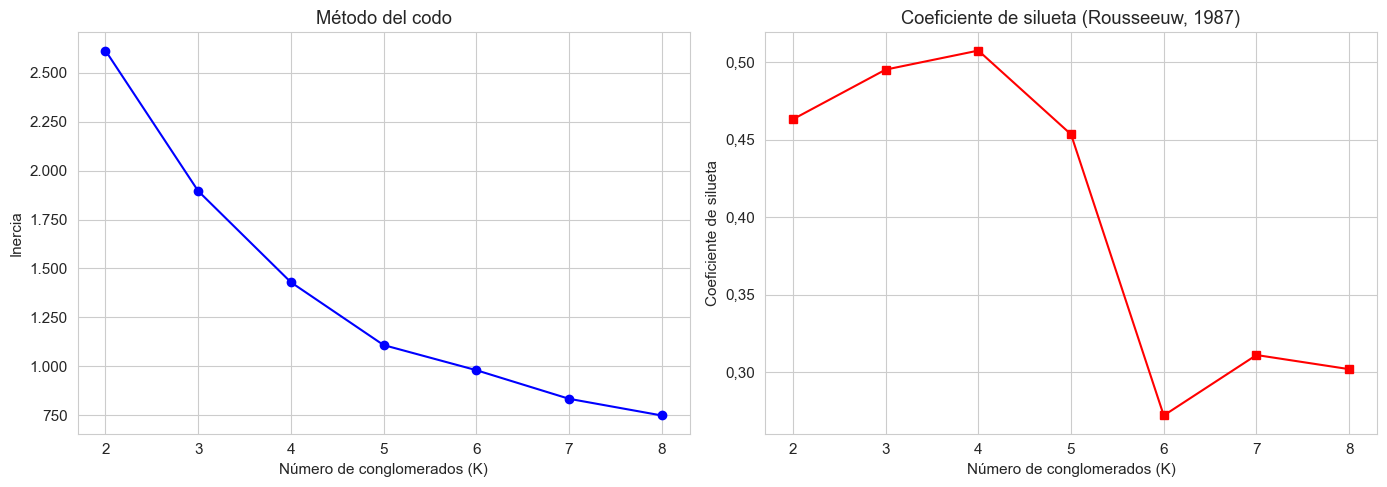


K óptimo por silueta: 4


In [5]:
# =============================================
# SELECCIÓN DE K (MÉTODO DEL CODO + COEFICIENTE DE SILUETA)
# =============================================

inertias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cluster, labels)
    silhouette_scores.append(sil)
    print(f"K={k}: inercia={km.inertia_:.0f}, silhouette={sil:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Número de conglomerados (K)')
ax1.set_ylabel('Inercia')
ax1.yaxis.set_major_formatter(eje_co())
ax1.set_title('Método del codo')

ax2.plot(K_range, silhouette_scores, 'rs-')
ax2.set_xlabel('Número de conglomerados (K)')
ax2.set_ylabel('Coeficiente de silueta')
ax2.yaxis.set_major_formatter(eje_co(2))
ax2.set_title('Coeficiente de silueta (Rousseeuw, 1987)')

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig3_elbow_silhouette.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nK óptimo por silueta: {list(K_range)[silhouette_scores.index(max(silhouette_scores))]}")

### Partición final: K = 4

Ambos criterios coinciden en K=4 (máximo del coeficiente de silueta y codo de la curva de inercia) y la partición produce cuatro perfiles operativamente interpretables según el nivel y la forma de la presión (§3.7). La robustez de esta elección se valida en la sección 2.

In [6]:
# =============================================
# K-MEANS — K=4
# =============================================

K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
perfiles_pivot['cluster'] = km.fit_predict(X_cluster)

print("Resumen por conglomerado:\n")
for c in range(K):
    est_cluster = perfiles_pivot[perfiles_pivot['cluster'] == c]
    print(f"Conglomerado {c}: {len(est_cluster)} estaciones")
    print(f"  IPD promedio: {est_cluster['ipd_mean'].mean():.3f}")
    print(f"  IPD máximo:   {est_cluster['ipd_max'].mean():.3f}")
    print(f"  Estaciones:   {', '.join(est_cluster.index[:5])}")
    if len(est_cluster) > 5:
        print(f"                ... y {len(est_cluster)-5} más")
    print()

cluster_df = perfiles_pivot[['cluster', 'ipd_mean', 'ipd_max']].reset_index()

Resumen por conglomerado:

Conglomerado 0: 14 estaciones
  IPD promedio: 0.177
  IPD máximo:   0.785
  Estaciones:   AV. 1° Mayo, Banderas, Bosa, Portal 20 de Julio, Portal 80
                ... y 9 más

Conglomerado 1: 33 estaciones
  IPD promedio: 0.181
  IPD máximo:   0.715
  Estaciones:   AV. Chile, AV. Jiménez, Calle 100 - Marketmedios, Calle 106, Calle 127
                ... y 28 más

Conglomerado 2: 99 estaciones
  IPD promedio: 0.067
  IPD máximo:   0.270
  Estaciones:   21 Ángeles, 7 de agosto, AV. 39, AV. 68, AV. Américas - AV. Boyacá
                ... y 94 más

Conglomerado 3: 2 estaciones
  IPD promedio: 0.133
  IPD máximo:   0.543
  Estaciones:   Campín - UAN, Movistar Arena



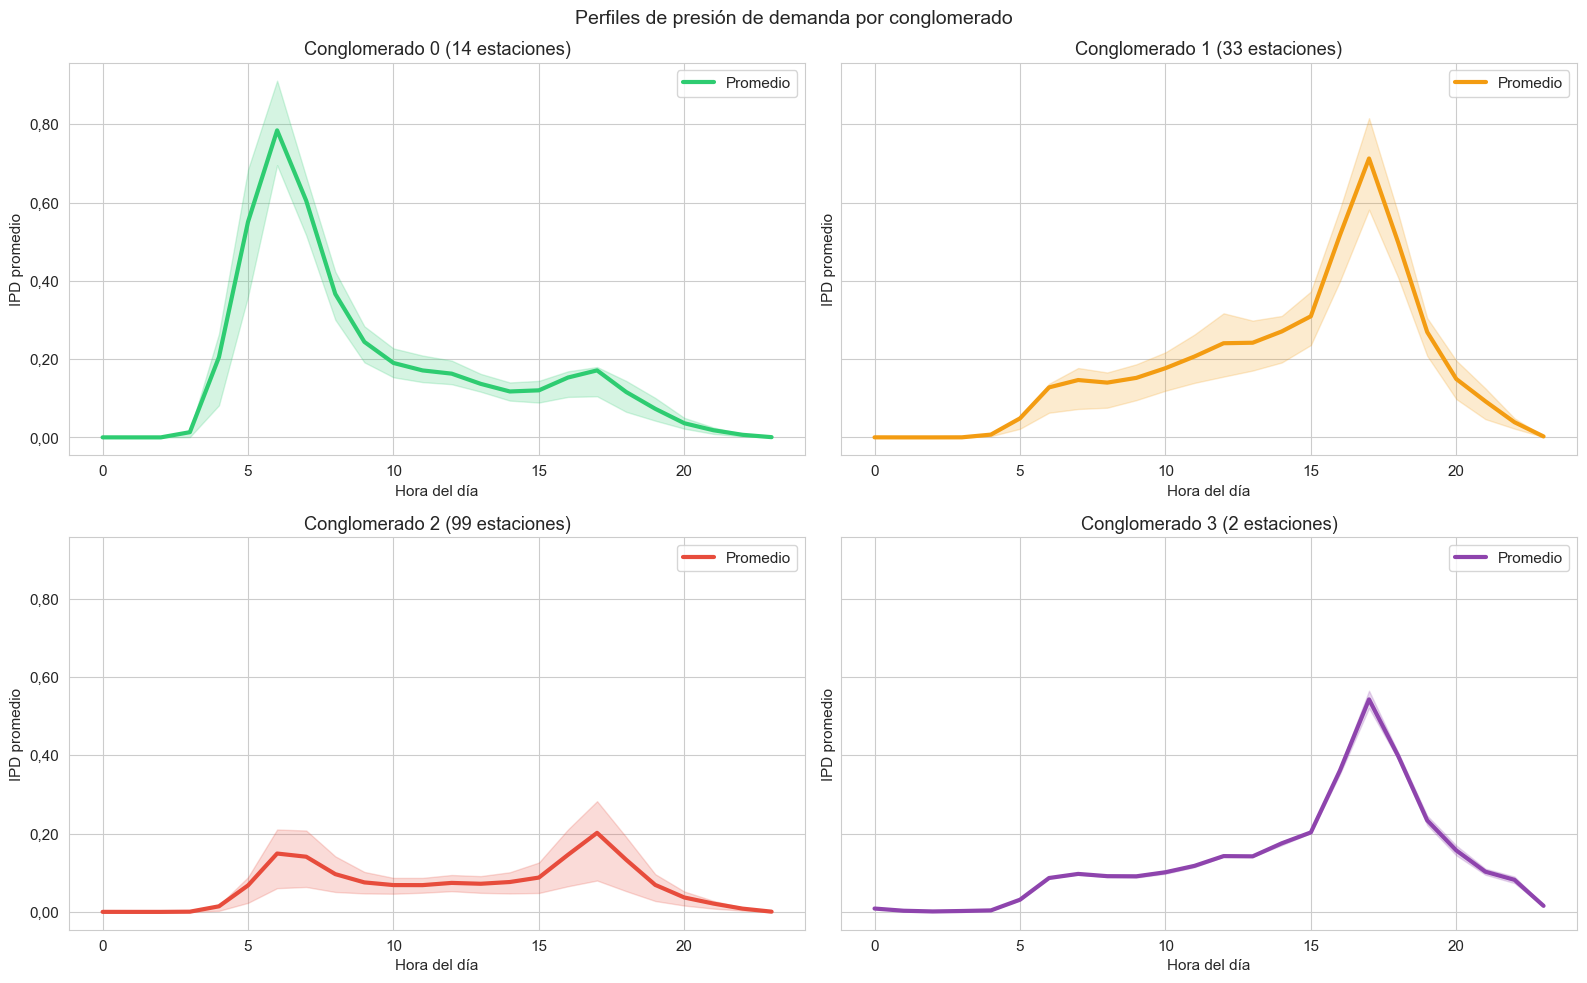

In [7]:
# =============================================
# PERFILES POR CONGLOMERADO
# =============================================

hora_cols = [c for c in perfiles_pivot.columns
             if c not in ['cluster', 'ipd_mean', 'ipd_std', 'ipd_max']
             and c.isdigit()]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']

for c in range(K):
    ax = axes[c // 2][c % 2]
    cluster_data = perfiles_pivot[perfiles_pivot['cluster'] == c][hora_cols]
    mean_profile = cluster_data.mean()
    x = [int(h) for h in mean_profile.index]
    ax.plot(x, mean_profile.values, color=colors[c], linewidth=3, label='Promedio')
    ax.fill_between(x,
                    cluster_data.quantile(0.25).values,
                    cluster_data.quantile(0.75).values,
                    alpha=0.2, color=colors[c])
    ax.set_title(f'Conglomerado {c} ({len(cluster_data)} estaciones)')
    ax.set_xlabel('Hora del día')
    ax.set_ylabel('IPD promedio')
    ax.yaxis.set_major_formatter(eje_co(2))
    ax.legend()

plt.suptitle('Perfiles de presión de demanda por conglomerado', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig4_perfiles_conglomerados.png'), dpi=150, bbox_inches='tight')
plt.show()

### Análisis complementario (exploratorio): clustering solo con horas pico

**No hace parte del protocolo de §3.7** y no alimenta los cuadernos siguientes: la tipología oficial es la de día completo (celdas anteriores). Se reporta como verificación de que esa tipología no está dominada por las horas valle: si al agrupar usando solo los picos (6–9 y 17–20) las estaciones clave cambian poco de grupo, el perfil de día completo es representativo.

La concordancia entre ambas particiones se cuantifica con el ARI y con una tabla de cruce con etiquetas alineadas por solapamiento mayoritario, porque las etiquetas numéricas de cada solución son arbitrarias y no comparables directamente.


Silueta K=4 (solo picos): 0.388
Silueta K=4 (todo el día): 0.508

CLUSTERING SOLO HORAS PICO (6-9 + 17-20)

Cluster 0: 79 estaciones
  IPD medio: 0.102
  IPD máx:   0.228
  Estaciones: Restrepo, Alcalá - Col. S. Tomás Dominicos, Biblioteca Tintal, Country Sur, Hortúa, Alquería, Santa Lucía, Normandía
              ... y 71 más

Cluster 1: 33 estaciones
  IPD medio: 0.174
  IPD máx:   0.478
  Estaciones: Temporal - Calle 34, Suba - Calle 100, Héroes, NQS - Calle 38A S., Movistar Arena, Zona Industrial, Campín - UAN, Calle 127
              ... y 25 más

Cluster 2: 16 estaciones
  IPD medio: 0.298
  IPD máx:   0.743
  Estaciones: Portal 80, Portal Norte, Portal Tunal, Portal Américas, Portal Eldorado - C.C. NUESTRO BOGOTÁ, Portal Suba, San Mateo, Portal Sur - JFK Coop. financ.
              ... y 8 más

Cluster 3: 20 estaciones
  IPD medio: 0.313
  IPD máx:   0.835
  Estaciones: Pradera - Plaza Central, Calle 100 - Marketmedios, Museo del Oro, Temporal - Flores, KR 53, San Victorino, Cal

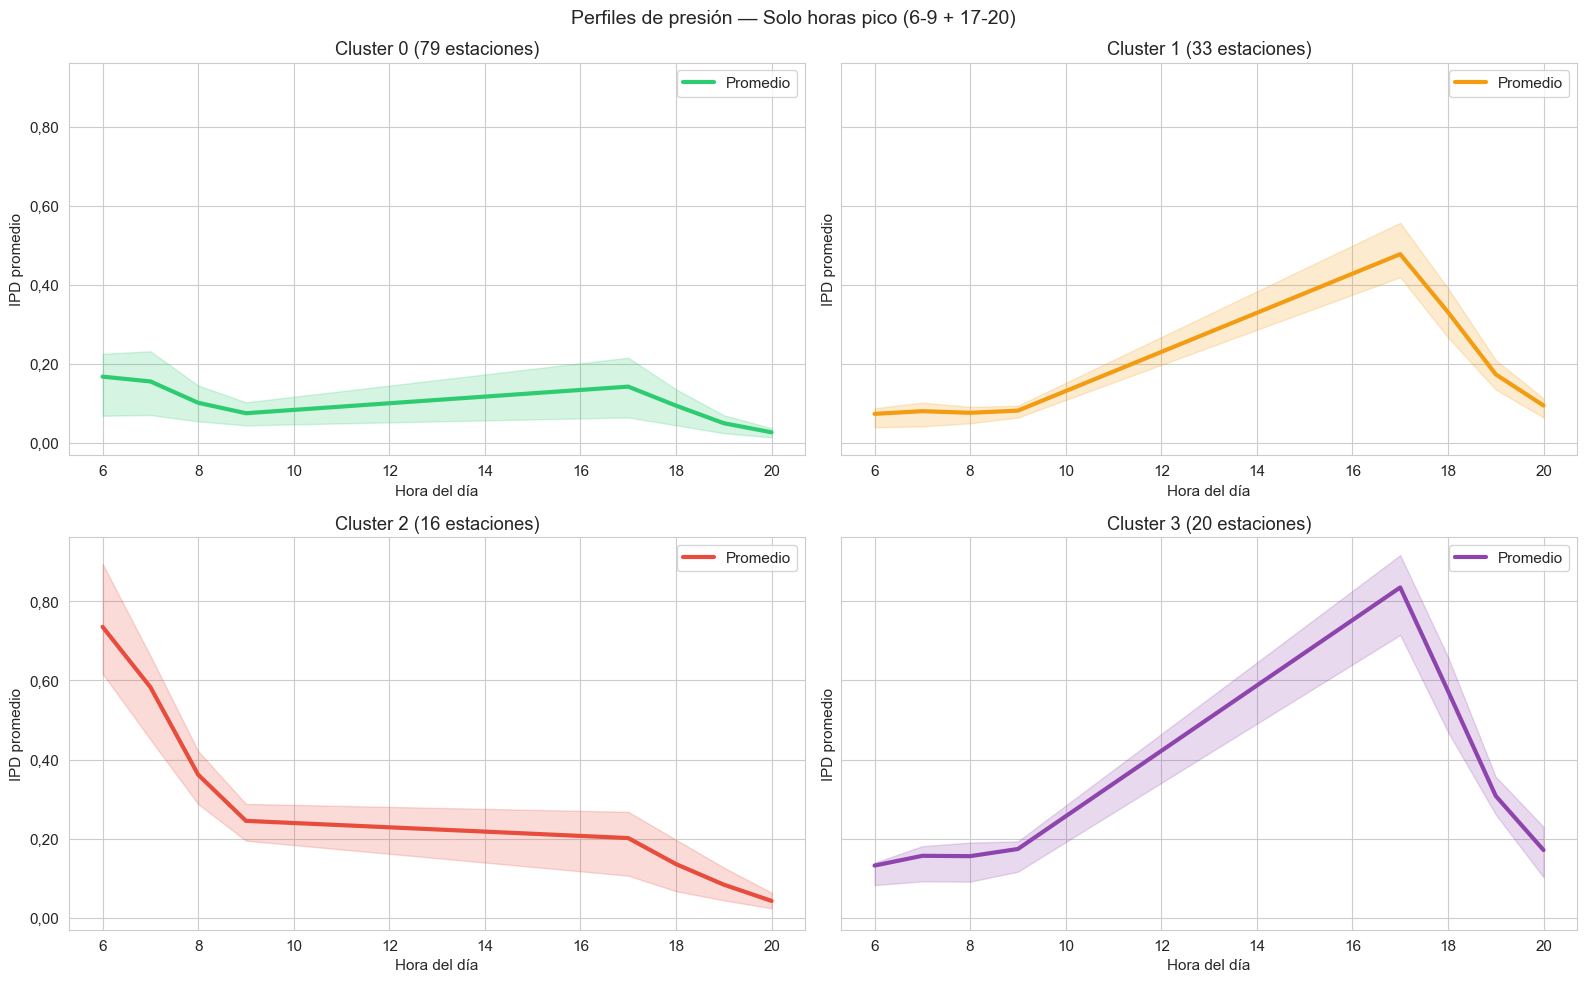

In [8]:
# =============================================
# ANÁLISIS COMPLEMENTARIO: CLUSTERING SOLO HORAS PICO
# =============================================

# Filtrar solo picos AM (6-9) y PM (17-20)
pico = habiles[
    (habiles['hora'].between(6, 9)) | 
    (habiles['hora'].between(17, 20))
]

perfiles_pico = pico.groupby(['estacion', 'hora'])['ipd'].mean().reset_index()
pivot_pico = perfiles_pico.pivot(index='estacion', columns='hora', values='ipd').fillna(0)
pivot_pico['ipd_mean'] = pivot_pico.mean(axis=1)
pivot_pico['ipd_max'] = pivot_pico.max(axis=1)
pivot_pico.columns = pivot_pico.columns.astype(str)

X_pico = StandardScaler().fit_transform(pivot_pico)

# K=4 con solo horas pico
km_pico = KMeans(n_clusters=4, random_state=42, n_init=10)
pivot_pico['cluster_pico'] = km_pico.fit_predict(X_pico)
sil_pico = silhouette_score(X_pico, pivot_pico['cluster_pico'])

print(f"Silueta K=4 (solo picos): {sil_pico:.3f}")
print(f"Silueta K=4 (todo el día): {silhouette_scores[2]:.3f}")  # index 2 = K=4

# Ordenar clusters por IPD medio
cluster_order = pivot_pico.groupby('cluster_pico')['ipd_mean'].mean().sort_values()
label_map = {old: new for new, old in enumerate(cluster_order.index)}
pivot_pico['cluster_pico_ord'] = pivot_pico['cluster_pico'].map(label_map)

print(f"\n{'='*60}")
print("CLUSTERING SOLO HORAS PICO (6-9 + 17-20)")
print(f"{'='*60}")

for c in range(4):
    sub = pivot_pico[pivot_pico['cluster_pico_ord'] == c].sort_values('ipd_mean', ascending=False)
    print(f"\nCluster {c}: {len(sub)} estaciones")
    print(f"  IPD medio: {sub['ipd_mean'].mean():.3f}")
    print(f"  IPD máx:   {sub['ipd_max'].mean():.3f}")
    print(f"  Estaciones: {', '.join(sub.index[:8])}")
    if len(sub) > 8:
        print(f"              ... y {len(sub)-8} más")

# Correspondencia entre la partición de día completo y la de solo picos.
# Las etiquetas 0-3 de cada solución son arbitrarias: comparar el número de
# etiqueta no significa nada. Paso 1: concordancia global con el ARI
# (invariante a la numeración). Paso 2: alinear etiquetas por solapamiento
# mayoritario para poder hablar de estaciones que "cambian" de grupo.

comunes  = perfiles_pivot.index.intersection(pivot_pico.index)
lab_dia  = perfiles_pivot.loc[comunes, 'cluster'].astype(int)
lab_pico = pivot_pico.loc[comunes, 'cluster_pico_ord'].astype(int)

ari_dia_pico = adjusted_rand_score(lab_dia, lab_pico)
print(f"\n{'='*60}")
print("CORRESPONDENCIA DÍA COMPLETO vs SOLO PICOS")
print(f"{'='*60}")
print(f"ARI entre ambas particiones: {ari_dia_pico:.3f}")

tabla_cruce = pd.crosstab(lab_pico, lab_dia)
print("\nCruce picos (filas) vs día completo (columnas):")
print(tabla_cruce.to_string())

equiv = tabla_cruce.idxmax(axis=1).to_dict()
lab_pico_alineada = lab_pico.map(equiv)

pct_permanece = (lab_pico_alineada == lab_dia).mean()
cambian = comunes[(lab_pico_alineada != lab_dia).values]
print(f"\nEstaciones que permanecen en el grupo equivalente: {pct_permanece:.1%}")
print(f"Estaciones que cambian de grupo ({len(cambian)}):")
for est in cambian:
    print(f"  {est}: día completo = {lab_dia[est]}  ->  picos (equivalente) = {lab_pico_alineada[est]}")

# Perfiles visuales
hora_cols_pico = [c for c in pivot_pico.columns 
                  if c not in ['cluster_pico', 'cluster_pico_ord', 'ipd_mean', 'ipd_max', 'ipd_std']
                  and c.isdigit()]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']

for c in range(4):
    ax = axes[c // 2][c % 2]
    cluster_data = pivot_pico[pivot_pico['cluster_pico_ord'] == c][hora_cols_pico]
    mean_profile = cluster_data.mean()
    x = [int(h) for h in mean_profile.index]
    ax.plot(x, mean_profile.values, color=colors[c], linewidth=3, label='Promedio')
    ax.fill_between(x,
                    cluster_data.quantile(0.25).values,
                    cluster_data.quantile(0.75).values,
                    alpha=0.2, color=colors[c])
    ax.set_title(f'Cluster {c} ({len(cluster_data)} estaciones)')
    ax.set_xlabel('Hora del día')
    ax.set_ylabel('IPD promedio')
    ax.yaxis.set_major_formatter(eje_co(2))
    ax.legend()

plt.suptitle('Perfiles de presión — Solo horas pico (6-9 + 17-20)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig_perfiles_solo_picos.png'), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# =============================================
# ASIGNACION DEL CONGLOMERADO AL DATASET COMPLETO
# =============================================
# Se mapea la etiqueta de conglomerado de cada estacion (cluster_df) sobre
# el dataset completo ipd_df, para los analisis posteriores por conglomerado
# (boxplot, pruebas estadisticas y modelo).

cluster_map = cluster_df.set_index('estacion')['cluster'].to_dict()
ipd_df['cluster'] = ipd_df['estacion'].map(cluster_map)
print(f"Conglomerado asignado a {ipd_df['cluster'].notna().sum():,} registros "
      f"({int(ipd_df['cluster'].nunique())} conglomerados).")


Conglomerado asignado a 8,192,438 registros (4 conglomerados).


Panel por conglomerado (hábiles no festivos): 5,502,465 filas


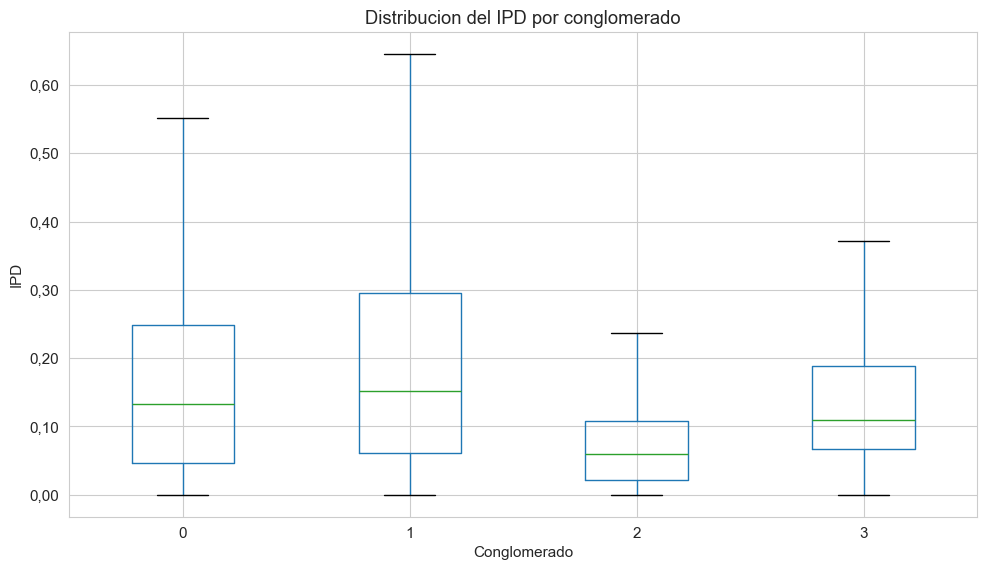

Estadisticas descriptivas del IPD por conglomerado:
             count   mean    std  min    25%    50%    75%    max
cluster                                                          
0         565911.0  0.206  0.233  0.0  0.047  0.132  0.249  2.328
1        1208918.0  0.217  0.222  0.0  0.062  0.152  0.295  2.689
2        3647006.0  0.082  0.089  0.0  0.022  0.059  0.108  1.556
3          80630.0  0.155  0.156  0.0  0.067  0.110  0.189  2.227


In [10]:
# =============================================
# DISTRIBUCION DEL IPD POR CONGLOMERADO
# =============================================

# Misma base que la tipología: días hábiles no festivos (§3.4; coherente con
# lo ya anunciado en §4.3.1 del documento para las comparaciones).
ipd_df_cl = ipd_df[(ipd_df['cluster'].notna()) &
                   (ipd_df['dia_semana'] < 5) &
                   (ipd_df['es_festivo'] == 0)].copy()
ipd_df_cl['cluster'] = ipd_df_cl['cluster'].astype(int)
print(f"Panel por conglomerado (hábiles no festivos): {len(ipd_df_cl):,} filas")

fig, ax = plt.subplots(figsize=(10, 6))
ipd_df_cl.boxplot(column='ipd', by='cluster', ax=ax, showfliers=False)
ax.set_title('Distribucion del IPD por conglomerado')
ax.set_xlabel('Conglomerado')
ax.set_ylabel('IPD')
ax.yaxis.set_major_formatter(eje_co(2))
plt.suptitle('')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig_ipd_por_conglomerado.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Estadisticas descriptivas del IPD por conglomerado:")
print(ipd_df_cl.groupby('cluster')['ipd'].describe().round(3).to_string())


## 2. Validación de los conglomerados (§3.7)

Tres verificaciones, cada una contra un riesgo distinto:

- **Silueta por estación:** detecta estaciones mal asignadas (silueta negativa = más cerca de otro grupo que del propio). Las que aparezcan se reportan como casos frontera: se mantienen en su grupo, pero su tipología se lee con cautela.
- **Estabilidad ante inicializaciones:** K-Means depende de los centroides iniciales. Se corre 20 veces con semillas distintas y se mide la concordancia entre corridas con el **índice de Rand ajustado** (ARI: 1 = particiones idénticas; 0 = coincidencia esperable por azar). Veinte corridas generan 190 pares, suficientes para estimar la dispersión del ARI a bajo costo.
- **Contraste con agrupamiento jerárquico (Ward):** un algoritmo de lógica distinta (aglomerativo, sin inicialización aleatoria) sobre los mismos datos. Si su partición concuerda con la de K-Means (ARI alto), la estructura encontrada no es un artefacto del algoritmo (§3.7).

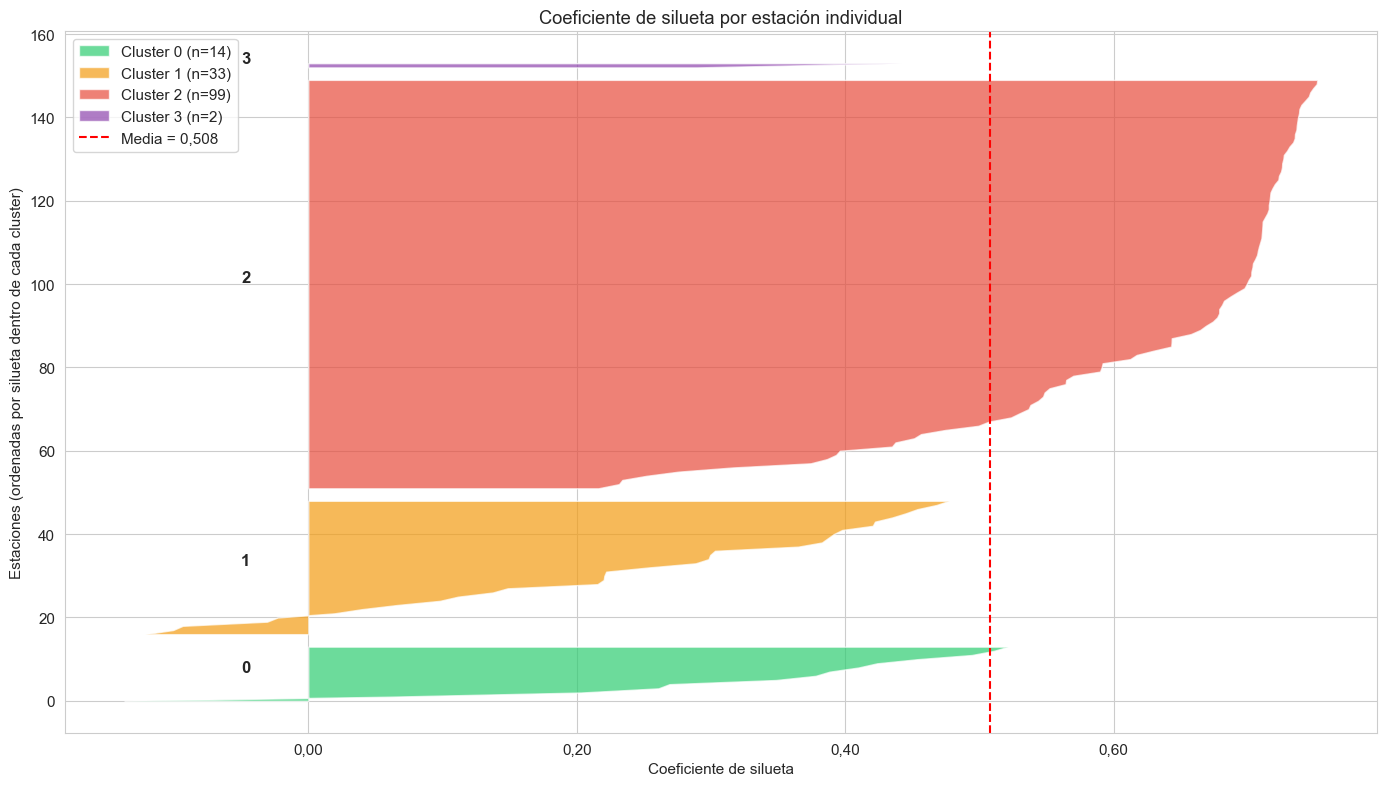

Estaciones con silueta negativa: 6
  AV. 1° Mayo                               cluster=0  silueta=-0.137
  Calle 127                                 cluster=1  silueta=-0.122
  Comuneros                                 cluster=1  silueta=-0.094
  De la Sabana                              cluster=1  silueta=-0.031
  Las Nieves                                cluster=1  silueta=-0.101
  Policarpa                                 cluster=1  silueta=-0.023


In [11]:
# =============================================
# SILUETA POR ESTACIÓN INDIVIDUAL
# =============================================

from sklearn.metrics import silhouette_samples

sil_samples = silhouette_samples(X_cluster, perfiles_pivot['cluster'].values)
perfiles_pivot['silhouette'] = sil_samples

fig, ax = plt.subplots(figsize=(14, 8))
y_lower = 0
colors_cl = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']

for c in range(K):
    cluster_sil = np.sort(sil_samples[perfiles_pivot['cluster'].values == c])
    size = len(cluster_sil)
    y_upper = y_lower + size
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                      facecolor=colors_cl[c], alpha=0.7, label=f'Cluster {c} (n={size})')
    ax.text(-0.05, y_lower + 0.5 * size, str(c), fontweight='bold', fontsize=12)
    y_lower = y_upper + 2

ax.axvline(x=sil_samples.mean(), color='red', linestyle='--',
           label=f'Media = {num_co(sil_samples.mean(), 3)}')
ax.set_xlabel('Coeficiente de silueta')
ax.xaxis.set_major_formatter(eje_co(2))
ax.set_ylabel('Estaciones (ordenadas por silueta dentro de cada cluster)')
ax.set_title('Coeficiente de silueta por estación individual')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig_silueta_individual.png'), dpi=150, bbox_inches='tight')
plt.show()

# Estaciones con silueta negativa (mal asignadas)
mal_asignadas = perfiles_pivot[perfiles_pivot['silhouette'] < 0]
print(f"Estaciones con silueta negativa: {len(mal_asignadas)}")
for est, row in mal_asignadas.iterrows():
    print(f"  {est:40s}  cluster={int(row['cluster'])}  silueta={row['silhouette']:.3f}")

=== ESTABILIDAD DE CLUSTERS (20 inicializaciones) ===
  ARI medio entre corridas: 0.971
  ARI mínimo:               0.806
  ARI máximo:               1.000
  DE:                        0.049
  -> Clusters ALTAMENTE ESTABLES.


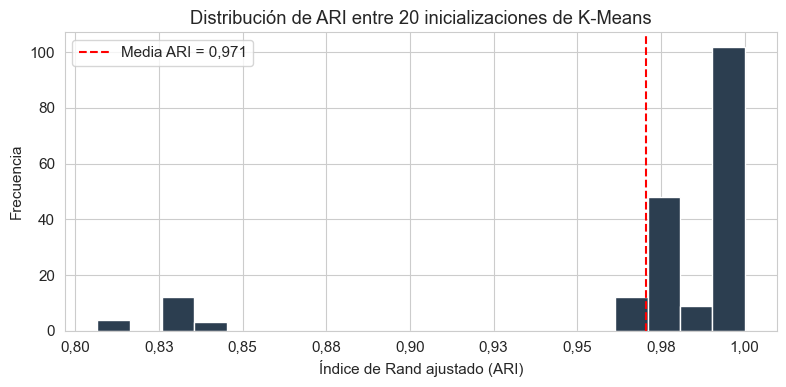

In [12]:
# =============================================
# ESTABILIDAD DE CLUSTERS (MÚLTIPLES INICIALIZACIONES)
# =============================================

n_runs = 20
all_labels = []
for seed in range(n_runs):
    km_run = KMeans(n_clusters=K, random_state=seed, n_init=10)
    labels = km_run.fit_predict(X_cluster)
    all_labels.append(labels)

# ARI entre cada par de corridas
from itertools import combinations
ari_pairs = []
for i, j in combinations(range(n_runs), 2):
    ari_pairs.append(adjusted_rand_score(all_labels[i], all_labels[j]))

print(f"=== ESTABILIDAD DE CLUSTERS ({n_runs} inicializaciones) ===")
print(f"  ARI medio entre corridas: {np.mean(ari_pairs):.3f}")
print(f"  ARI mínimo:               {np.min(ari_pairs):.3f}")
print(f"  ARI máximo:               {np.max(ari_pairs):.3f}")
print(f"  DE:                        {np.std(ari_pairs):.3f}")

if np.mean(ari_pairs) > 0.9:
    print("  -> Clusters ALTAMENTE ESTABLES.")
elif np.mean(ari_pairs) > 0.7:
    print("  -> Clusters razonablemente estables.")
else:
    print("  -> Clusters INESTABLES — los resultados dependen de la inicialización.")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ari_pairs, bins=20, color='#2c3e50', edgecolor='white')
ax.axvline(x=np.mean(ari_pairs), color='red', linestyle='--',
           label=f'Media ARI = {num_co(np.mean(ari_pairs), 3)}')
ax.set_xlabel('Índice de Rand ajustado (ARI)')
ax.xaxis.set_major_formatter(eje_co(2))
ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribución de ARI entre {n_runs} inicializaciones de K-Means')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig_estabilidad_clusters.png'), dpi=150, bbox_inches='tight')
plt.show()

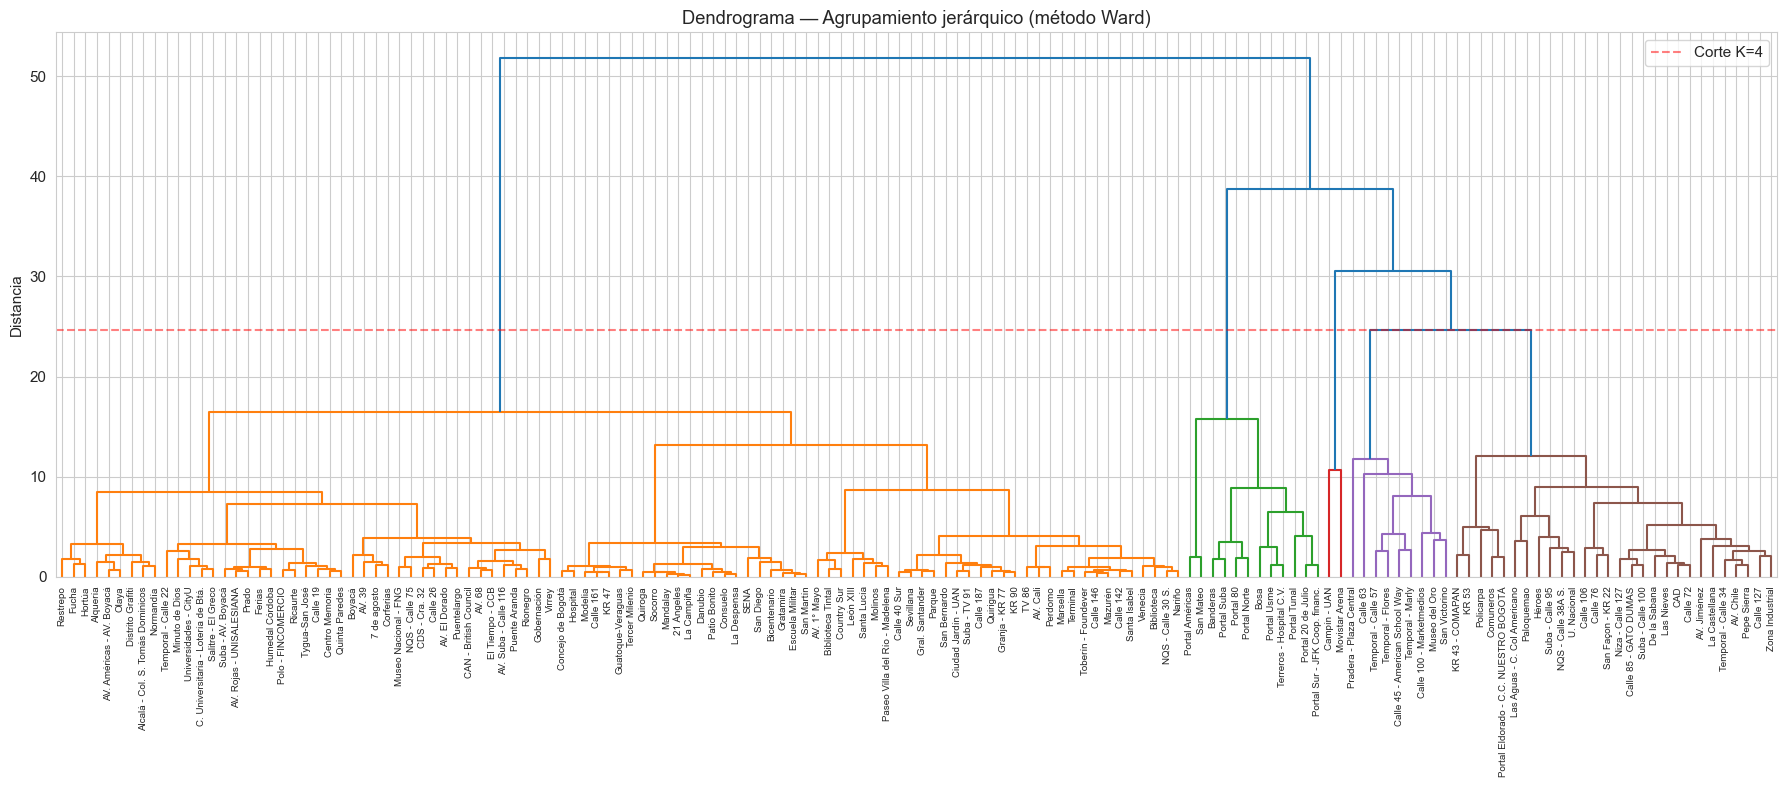

ARI entre K-Means y jerárquico (Ward): 0.900
  -> Alta concordancia, lo que valida la elección de K-Means.


In [13]:
# =============================================
# DENDROGRAMA (AGRUPAMIENTO JERÁRQUICO)
# =============================================

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

Z = linkage(X_cluster, method='ward')

fig, ax = plt.subplots(figsize=(18, 8))
dend = dendrogram(Z, labels=perfiles_pivot.index.values, leaf_rotation=90,
                  leaf_font_size=7, color_threshold=Z[-4, 2], ax=ax)  # corte en K=4
ax.set_title('Dendrograma — Agrupamiento jerárquico (método Ward)')
ax.set_ylabel('Distancia')
ax.yaxis.set_major_formatter(eje_co())
ax.axhline(y=Z[-4, 2], color='red', linestyle='--', alpha=0.5, label='Corte K=4')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG,'fig_dendrograma.png'), dpi=150, bbox_inches='tight')
plt.show()

# ARI entre jerárquico y K-Means
hier_labels = fcluster(Z, t=4, criterion='maxclust')
ari_hier = adjusted_rand_score(perfiles_pivot['cluster'].values, hier_labels)
print(f"ARI entre K-Means y jerárquico (Ward): {ari_hier:.3f}")
if ari_hier > 0.7:
    print("  -> Alta concordancia, lo que valida la elección de K-Means.")

## 3. Pruebas estadísticas entre conglomerados (§3.7)

¿Los grupos difieren de forma estadísticamente significativa y no solo descriptiva? Se usa **Kruskal-Wallis** (y no ANOVA) porque la distribución del IPD no es normal —la normalidad se rechazó en OE1 (§3.6)— y la prueba compara por rangos sin ese supuesto. Como la prueba global solo indica que *algún* grupo difiere, se complementa con comparaciones **par a par de Mann-Whitney** con **corrección de Bonferroni**, que reparte el nivel de significancia entre las 6 comparaciones para controlar el error tipo I por multiplicidad (§3.7).

In [14]:
# =============================================
# KRUSKAL-WALLIS: DIFERENCIAS ENTRE CLUSTERS
# (misma base que la tipología: ipd_df_cl, días hábiles no festivos)
# =============================================

from scipy import stats
from itertools import combinations

def fmt_p(p):
    """Nunca reportar 0.00e+00: por debajo de 0.001 se informa '< 0.001'."""
    return "< 0.001" if p < 0.001 else f"= {p:.3f}"

clusters_unique = sorted(ipd_df_cl['cluster'].unique())
ipd_by_cluster = [ipd_df_cl[ipd_df_cl['cluster'] == c]['ipd'].values
                  for c in clusters_unique]

h_stat, p_value = stats.kruskal(*ipd_by_cluster)
print("=== KRUSKAL-WALLIS: IPD entre conglomerados (hábiles) ===")
print(f"  H = {h_stat:,.2f}, p {fmt_p(p_value)}")
print(f"  {'SIGNIFICATIVO' if p_value < 0.05 else 'No significativo'} (α = 0.05)")

n_tests = len(list(combinations(clusters_unique, 2)))
print(f"\n=== MANN-WHITNEY U — PAR A PAR (Bonferroni, {n_tests} comparaciones, "
      f"α corregido = {0.05/n_tests:.4f}) ===")
for c1, c2 in combinations(clusters_unique, 2):
    data1 = ipd_df_cl[ipd_df_cl['cluster'] == c1]['ipd'].values
    data2 = ipd_df_cl[ipd_df_cl['cluster'] == c2]['ipd'].values
    u, p = stats.mannwhitneyu(data1, data2, alternative='two-sided')
    sig = "significativo" if p < 0.05/n_tests else "no significativo"
    print(f"  Conglomerado {int(c1)} vs {int(c2)}: U = {u:,.0f}, p {fmt_p(p)} -> {sig}")


=== KRUSKAL-WALLIS: IPD entre conglomerados (hábiles) ===
  H = 602,872.69, p < 0.001
  SIGNIFICATIVO (α = 0.05)

=== MANN-WHITNEY U — PAR A PAR (Bonferroni, 6 comparaciones, α corregido = 0.0083) ===
  Conglomerado 0 vs 1: U = 318,810,096,104, p < 0.001 -> significativo
  Conglomerado 0 vs 2: U = 1,395,004,632,036, p < 0.001 -> significativo
  Conglomerado 0 vs 3: U = 24,744,951,291, p < 0.001 -> significativo
  Conglomerado 1 vs 2: U = 3,150,128,200,231, p < 0.001 -> significativo
  Conglomerado 1 vs 3: U = 56,465,546,710, p < 0.001 -> significativo
  Conglomerado 2 vs 3: U = 97,539,867,618, p < 0.001 -> significativo


In [15]:
# =============================================
# VERIFICACIÓN A NIVEL ESTACIÓN (n = 148)
# =============================================
# Con 5,5 millones de filas casi cualquier diferencia da p < 0,001. Se repiten
# las pruebas con UNA observación por estación (su IPD medio en días hábiles,
# la misma base de la tipología) para mostrar que las diferencias no son un
# artefacto del tamaño muestral. Aviso: 0 vs 1 puede salir no significativo
# aquí, y es coherente: esos grupos se distinguen por la FORMA del perfil
# (mañana vs tarde), no por el nivel medio.

ipd_est = habiles.groupby('estacion')['ipd'].mean()
grupos_est = [ipd_est[perfiles_pivot.index[perfiles_pivot['cluster'] == c]].values
              for c in range(K)]

kw_est_H, kw_est_p = stats.kruskal(*grupos_est)
print("=== KRUSKAL-WALLIS A NIVEL ESTACIÓN (IPD medio en hábiles) ===")
print(f"  H = {kw_est_H:.2f}, p {fmt_p(kw_est_p)}")

mw_estacion = {}
print(f"\n=== MANN-WHITNEY PAR A PAR A NIVEL ESTACIÓN (Bonferroni, {n_tests} "
      f"comparaciones, α corregido = {0.05/n_tests:.4f}) ===")
for c1, c2 in combinations(range(K), 2):
    u, p = stats.mannwhitneyu(grupos_est[c1], grupos_est[c2], alternative='two-sided')
    sig = "significativo" if p < 0.05 / n_tests else "no significativo"
    aviso = "  [grupo con n = 2: poca potencia]" if min(len(grupos_est[c1]), len(grupos_est[c2])) < 5 else ""
    mw_estacion[f"{c1}_vs_{c2}"] = {'U': float(u), 'p': round(float(p), 4), 'resultado': sig}
    print(f"  {c1} vs {c2} (n = {len(grupos_est[c1])}, {len(grupos_est[c2])}): "
          f"U = {u:.0f}, p = {p:.4f} -> {sig}{aviso}")


=== KRUSKAL-WALLIS A NIVEL ESTACIÓN (IPD medio en hábiles) ===
  H = 97.76, p < 0.001

=== MANN-WHITNEY PAR A PAR A NIVEL ESTACIÓN (Bonferroni, 6 comparaciones, α corregido = 0.0083) ===
  0 vs 1 (n = 14, 33): U = 210, p = 0.6335 -> no significativo
  0 vs 2 (n = 14, 99): U = 1383, p = 0.0000 -> significativo
  0 vs 3 (n = 14, 2): U = 25, p = 0.1000 -> no significativo  [grupo con n = 2: poca potencia]
  1 vs 2 (n = 33, 99): U = 3266, p = 0.0000 -> significativo
  1 vs 3 (n = 33, 2): U = 59, p = 0.0672 -> no significativo  [grupo con n = 2: poca potencia]
  2 vs 3 (n = 99, 2): U = 0, p = 0.0004 -> significativo  [grupo con n = 2: poca potencia]


In [16]:
# =============================================
# EXPORTA ARTEFACTOS DE VALIDACIÓN (condición 1 de la entrega)
# =============================================

import json

validacion = {
    'fecha_ejecucion': pd.Timestamp.now().strftime('%Y-%m-%d'),
    'n_estaciones': int(X_cluster.shape[0]),
    'n_variables': int(X_cluster.shape[1]),
    'silueta_por_K': {int(k): round(float(s), 3) for k, s in zip(K_range, silhouette_scores)},
    'K_elegido': int(K),
    'silueta_K_elegido': round(float(silhouette_scores[list(K_range).index(K)]), 3),
    'estabilidad_inicializaciones': {
        'corridas': int(n_runs),
        'pares_comparados': len(ari_pairs),
        'ari_medio': round(float(np.mean(ari_pairs)), 3),
        'ari_min': round(float(np.min(ari_pairs)), 3),
        'ari_max': round(float(np.max(ari_pairs)), 3),
        'ari_de': round(float(np.std(ari_pairs)), 3),
    },
    'ari_kmeans_vs_ward': round(float(ari_hier), 3),
    'estaciones_silueta_negativa': {
        est: round(float(row['silhouette']), 3) for est, row in mal_asignadas.iterrows()
    },
    'kruskal_wallis_habiles': {'H': round(float(h_stat), 2), 'p': float(p_value)},
    'nivel_estacion': {
        'kruskal_wallis': {'H': round(float(kw_est_H), 2), 'p': round(float(kw_est_p), 6)},
        'mann_whitney_bonferroni': mw_estacion,
    },
    'sensibilidad_solo_picos': {
        'silueta_picos': round(float(sil_pico), 3),
        'ari_dia_vs_picos': round(float(ari_dia_pico), 3),
        'pct_permanencia_grupo_equivalente': round(float(pct_permanece), 3),
    },
}

ruta_val = os.path.join(OUT_TAB, 'validacion_conglomerados.json')
with open(ruta_val, 'w', encoding='utf-8') as f:
    json.dump(validacion, f, ensure_ascii=False, indent=2)
print(f"Guardado {ruta_val}")


Guardado c:\Users\ivanr\OneDrive\Desktop\Transmilenio Data\outputs\tablas\validacion_conglomerados.json


In [17]:
# === GUARDA EL PANEL CON CONGLOMERADO (costura hacia OE5) ===
import os; os.makedirs(DATA_INT, exist_ok=True); os.makedirs(OUT_TAB, exist_ok=True)
ipd_df.to_parquet(os.path.join(DATA_INT, 'panel_con_clusters.parquet'), index=False)
cluster_df.to_parquet(os.path.join(DATA_INT, 'cluster_df.parquet'), index=False)
cluster_df.to_csv(os.path.join(OUT_TAB, 'conglomerados_por_estacion.csv'), index=False)
print(f'Guardado panel_con_clusters ({len(ipd_df):,} filas) y cluster_df ({len(cluster_df)} estaciones)')


Guardado panel_con_clusters (8,192,438 filas) y cluster_df (148 estaciones)
